# GDELT GKG - Source Data Validation

> Test in [Google Colab](https://colab.research.google.com/)

We download one full day of GKG files and check every important column. For each one we ask:

By the end, we have a clear picture of the data quality and know exactly what the pipeline needs to handle.

---
## Section 1 - Setup

We import the libraries we need and define the constants and functions that every cell in this notebook depends on.

**#1** - Imports and constants


In [1]:
import io
import re
import zipfile
from collections import Counter
from datetime import date, timedelta

import matplotlib.pyplot as plt
import pandas as pd
import requests


# --- Constants ---

MASTER_URL      = "http://data.gdeltproject.org/gdeltv2/masterfilelist-translation.txt"
MIN_WORD_COUNT  = 100

GKG_COLUMNS = [
    "GKGRECORDID",
    "DATE",
    "SOURCECOLLECTIONIDENTIFIER",
    "SOURCECOMMONNAME",
    "DOCUMENTIDENTIFIER",
    "COUNTS",
    "ENHANCEDCOUNTS",
    "THEMES",
    "ENHANCEDTHEMES",
    "LOCATIONS",
    "ENHANCEDLOCATIONS",
    "PERSONS",
    "ENHANCEDPERSONS",
    "ORGANIZATIONS",
    "ENHANCEDORGANIZATIONS",
    "TONE",
    "ENHANCEDDATES",
    "GCAM",
    "SHARINGIMAGE",
    "RELATEDIMAGES",
    "SOCIALIMAGEEMBEDS",
    "SOCIALVIDEOEMBEDS",
    "QUOTATIONS",
    "ALLNAMES",
    "AMOUNTS",
    "TRANSLATIONINFO",
    "EXTRASXML",
]


# --- Display Functions ---

def print_section_header(title):
    """
    Prints a formatted section header to separate validation blocks.

    Args:
        title (str): The section title to display.
    """
    separator = "-" * 70
    print(f"\n{separator}")
    print(f"  {title}")
    print(f"{separator}")


def print_null_report(dataframe, column_name):
    """
    Prints how many values are missing in a column.

    Args:
        dataframe (pd.DataFrame): The source DataFrame.
        column_name (str):        Column to inspect.
    """
    total_rows      = len(dataframe)
    null_count      = dataframe[column_name].isna().sum()
    null_percentage = null_count / total_rows * 100 if total_rows else 0
    print(f"  Nulls: {null_count:,} / {total_rows:,} ({null_percentage:.2f}%)")

**#2** - Field parsers functions

Field parsers we use to read each raw GDELT field into a usable format.

In [2]:
# --- Tone Field ---

TONE_FIELDS = [
    "tone",
    "positive_score",
    "negative_score",
    "polarity",
    "activity_reference_density",
    "self_group_reference_density",
    "word_count",
]


def parse_tone(raw_string):
    """
    Parses the GKG Tone field into a dictionary.

    The Tone field is a comma-separated string with 7 numeric values.
    We use 'tone' (index 0) as the sentiment score and 'word_count' (index 6)
    to filter out short articles.

    Args:
        raw_string (str | None): Raw Tone string from a GKG record.

    Returns:
        dict | None: Dictionary with tone sub-fields, or None if parsing fails.
    """
    if not raw_string or not isinstance(raw_string, str):
        return None
    parts = raw_string.split(",")

    if len(parts) != 7:
        return None

    try:
        numeric_values = [float(part) for part in parts[:6]] + [int(parts[6])]
    except ValueError:
        return None
    return dict(zip(TONE_FIELDS, numeric_values))


# --- Location Field ---

def parse_locations(raw_string):
    """
    Parses the GKG Locations field into a list of location dictionaries.

    Each location entry is separated by semicolons and has fields separated by '#'.

    Args:
        raw_string (str | None): Raw Locations string from a GKG record.

    Returns:
        list[dict]: List of location dictionaries, empty if parsing fails.
    """
    if not raw_string or not isinstance(raw_string, str):
        return []

    all_locations = []
    for raw_entry in raw_string.split(";"):
        entry = raw_entry.strip()
        if not entry:
            continue
        parts = entry.split("#")
        if len(parts) < 8:
            continue
        parts[-1] = parts[-1].split(",")[0]
        try:
            all_locations.append({
                "location_type":         parts[0],
                "location_fullname":     parts[1],
                "location_country_code": parts[2],
                "location_adm1_code":    parts[3],
                "location_adm2_code":    parts[4],
                "location_latitude":     float(parts[5]) if parts[5] else None,
                "location_longitude":    float(parts[6]) if parts[6] else None,
                "location_feature_id":   parts[7] if len(parts) > 7 else "",
            })
        except (ValueError, IndexError):
            continue
    return all_locations


# --- Enhanced Field (Themes, Persons, Organizations) ---

def parse_enhanced_field(raw_string):
    """
    Parses a GKG enhanced field into a list of (value, offset) pairs.

    Enhanced fields (like ENHANCEDTHEMES) contain semicolon-separated entries.
    Each entry has the form "value,offset" where offset is a character position.
    We use rpartition to split on the last comma so theme names with commas
    in them are preserved correctly.

    Args:
        raw_string (str | None): Raw enhanced field string from a GKG record.

    Returns:
        list[tuple[str, int]]: List of (value, offset) pairs, empty if parsing fails.
    """
    if not raw_string or not isinstance(raw_string, str):
        return []

    parsed_entries = []
    for raw_entry in raw_string.split(";"):
        entry = raw_entry.strip()
        if "," not in entry:
            continue
        value, _, offset_string = entry.rpartition(",")
        try:
            parsed_entries.append((value, int(offset_string)))
        except ValueError:
            continue
    return parsed_entries


# --- Translation Info Field ---

def parse_translationinfo(raw_string):
    """
    Extracts the source language code from the TRANSLATIONINFO field.

    The field contains semicolon-separated key:value pairs. We look for
    the 'srclc:' key which holds the original article language code.

    Args:
        raw_string (str | None): Raw TRANSLATIONINFO string from a GKG record.

    Returns:
        str | None: ISO 639-2 language code, or None if not found.
    """
    if not raw_string or not isinstance(raw_string, str):
        return None

    for part in raw_string.split(";"):
        stripped_part = part.strip()
        if stripped_part.startswith("srclc:"):
            return stripped_part[len("srclc:"):]
    return None

print("Parsers Functions loaded.")

Parsers Functions loaded.


**#3** - Fetch the file list for the target date

GDELT publishes a master list of all available files. We fetch it and pull out the URLs for our target date.

Change `TARGET_DATE` to validate a different day.

In [3]:
TARGET_DATE = date.today() - timedelta(days=1)
date_prefix = TARGET_DATE.strftime("%Y%m%d")

print(f"Target date : {TARGET_DATE}")
print("Fetching master file list...")

master_response = requests.get(MASTER_URL, timeout=60)
master_response.raise_for_status()

all_urls = [
    line.strip().split()[-1]
    for line in master_response.text.strip().splitlines()
    if line.strip().endswith(".gkg.csv.zip") and date_prefix in line
]

print(f"Found {len(all_urls)} GKG translation files for {TARGET_DATE}")

Target date : 2026-06-01 00:00:00
Fetching master file list...
Found 96 GKG translation files for 2026-06-01 00:00:00


**#4** - Download and load all files

GDELT publishes a new file every 15 minutes - about 96 files per day. We download all of them, unzip each one, and combine them into a single table.

Re-run only when `TARGET_DATE` changes.

In [4]:
raw_frames  = []
error_count = 0
total_files = len(all_urls)

for file_index, url in enumerate(all_urls, start=1):
    try:
        file_response = requests.get(url, timeout=120, stream=True)
        file_response.raise_for_status()

        with zipfile.ZipFile(io.BytesIO(file_response.content)) as zip_archive:
            csv_filename = next(
                name
                for name in zip_archive.namelist()
                if name.lower().endswith(".csv")
            )
            with zip_archive.open(csv_filename) as csv_file:
                file_dataframe = pd.read_csv(
                    csv_file,
                    sep="\t",
                    header=None,
                    names=GKG_COLUMNS,
                    dtype=str,
                    encoding="latin-1",
                    on_bad_lines="warn",
                )
        raw_frames.append(file_dataframe)

        if file_index % 10 == 0 or file_index == total_files:
            print(f"  [{file_index}/{total_files}] loaded")

    except Exception as download_error:
        error_count += 1
        print(f"  ERROR [{file_index}] {url}: {download_error}")

raw_dataframe  = pd.concat(raw_frames, ignore_index=True)
total_articles = len(raw_dataframe)

print(f"\nLoad complete")
print(f"  Files loaded       : {total_files - error_count} / {total_files}")
print(f"  Download errors    : {error_count}")
print(f"  Total raw articles : {total_articles:,}")

  [10/96] loaded
  [20/96] loaded
  [30/96] loaded
  [40/96] loaded
  [50/96] loaded
  [60/96] loaded
  [70/96] loaded
  [80/96] loaded
  [90/96] loaded
  [96/96] loaded

Load complete
  Files loaded       : 96 / 96
  Download errors    : 0
  Total raw articles : 218,394


---
## Section 2 - Overview

**#5** - Column overview

We print every column with its null rate and a sample value.

In [5]:
total_rows = len(raw_dataframe)

print(f"Total raw articles : {total_rows:,}")
print()
print(f"{'COLUMN':<40} {'NON-NULL':>10} {'NULL%':>8}    SAMPLE VALUE")
print("-" * 100)

for column_name in raw_dataframe.columns:
    non_null_count  = raw_dataframe[column_name].notna().sum()
    null_percentage = (total_rows - non_null_count) / total_rows * 100
    sample_value    = raw_dataframe[column_name].dropna().iloc[1] if non_null_count > 1 else "(all null)"
    sample_preview  = str(sample_value).replace("\n", " ")
    print(f"  {column_name:<38} {non_null_count:>10,} {null_percentage:>7.2f}%   {sample_preview}")

Total raw articles : 218,394

COLUMN                                     NON-NULL    NULL%    SAMPLE VALUE
----------------------------------------------------------------------------------------------------
  GKGRECORDID                               218,394    0.00%   20260601000000-T1
  DATE                                      218,360    0.02%   20260601000000
  SOURCECOLLECTIONIDENTIFIER                218,360    0.02%   1
  SOURCECOMMONNAME                          218,360    0.02%   amarujala.com
  DOCUMENTIDENTIFIER                        218,360    0.02%   https://www.amarujala.com/world/trump-sends-back-iran-deal-text-with-changes-seeks-stricter-nuclear-commitments-hormuz-reopening-2026-06-01
  COUNTS                                     11,469   94.75%   ARREST#12#comment#0######;SOC_POINTSOFINTEREST_JAIL#12#comment#0######;ARREST#12#comment#0######;SOC_POINTSOFINTEREST_JAIL#12#comment#0######;
  ENHANCEDCOUNTS                             11,469   94.75%   ARREST#12#comment#0

**#6** - Fill rate

Sorting column by fill rate, ranked from most complete to least complete.

In [6]:
def compute_fill_rate(dataframe, column_name):
    """
    Returns what percentage of a column's values are non-null.

    Args:
        dataframe (pd.DataFrame): Source DataFrame.
        column_name (str):        Column to check.

    Returns:
        float: Fill rate as a percentage (0 to 100).
    """
    return dataframe[column_name].notna().sum() / len(dataframe) * 100


def get_fill_percentage(column_fill_tuple):
    """
    Extracts the fill percentage from a (column_name, fill_percentage) tuple.

    Used as the sort key when ranking columns by completeness.

    Args:
        column_fill_tuple (tuple): A (column_name, fill_percentage) pair.

    Returns:
        float: The fill percentage value.
    """
    return column_fill_tuple[1]


fill_rates = {
    column_name: compute_fill_rate(raw_dataframe, column_name)
    for column_name in raw_dataframe.columns
}

sorted_columns = sorted(fill_rates.items(), key=get_fill_percentage, reverse=True)

print(f"{'COLUMN':<40} {'FILL%':>8}    BAR")
print("-" * 80)

for column_name, fill_percentage in sorted_columns:
    bar_length = int(fill_percentage / 2)
    print(f"  {column_name:<38} {fill_percentage:>7.2f}%   {'#' * bar_length}")

COLUMN                                      FILL%    BAR
--------------------------------------------------------------------------------
  GKGRECORDID                             100.00%   ##################################################
  DATE                                     99.98%   #################################################
  SOURCECOLLECTIONIDENTIFIER               99.98%   #################################################
  SOURCECOMMONNAME                         99.98%   #################################################
  DOCUMENTIDENTIFIER                       99.98%   #################################################
  TONE                                     99.98%   #################################################
  GCAM                                     99.98%   #################################################
  TRANSLATIONINFO                          99.98%   #################################################
  EXTRASXML                                99

---
## Section 3 - Column Validation

In this section, we validate each column that is important to our pipeline. For each one we verify:
*   Are there any null values?
*   Is the data in the expected format?

We focus especially on the columns that our future pipeline will read and use directly.

### 3.1 - Record Identity

**#7** - GKGRECORDID: format check and duplicate investigation

GKGRECORDID is the unique identifier for each GKG record. The expected format is `YYYYMMDDHHMMSS-TN` (for example `20260618000000-T0`).

We first check for records that do not match this format. These invalid rows also have missing values in every other important field, so they are safe to drop.

We then look at duplicate IDs. Even though some GKGRECORDID values appear more than once, they always point to completely different articles URLs.

Since we intended to identify each article by its URL, this column is not needed by our future pipeline

In [7]:
# --- Check GKGRECORDID format and duplicates ---

print_section_header("GKGRECORDID")
print_null_report(raw_dataframe, "GKGRECORDID")

record_id_series  = raw_dataframe["GKGRECORDID"].dropna()
unique_id_count   = record_id_series.nunique()
total_id_count    = len(record_id_series)

print(f"  Unique IDs  : {unique_id_count:,}")
print(f"  Total IDs   : {total_id_count:,}")

gkgrecordid_pattern = re.compile(r"^\d{14}-T\d+$")


def matches_gkgrecordid_format(value):
    """
    Returns True if the value matches the expected GKGRECORDID format.

    Args:
        value: The raw record ID value.

    Returns:
        bool: True if the format matches, False otherwise.
    """
    return bool(gkgrecordid_pattern.match(str(value)))



gkgrecordid_valid_mask   = record_id_series.apply(matches_gkgrecordid_format)
gkgrecordid_invalid_mask = ~gkgrecordid_valid_mask
id_collision_mask   = gkgrecordid_valid_mask & record_id_series.duplicated(keep=False)

gkgrecordid_valid_count    = gkgrecordid_valid_mask.sum()
gkgrecordid_invalid_count  = gkgrecordid_invalid_mask.sum()
id_collision_count    = id_collision_mask.sum() // 2

print(f"\n  Format valid (YYYYMMDDHHMMSS-TN) : {gkgrecordid_valid_count:,} ")
print(f"  Format invalid                   : {gkgrecordid_invalid_count:,} ")
print(f"  ID collisions (pairs)            : {id_collision_count:,} ")


# --- Duplicated GKGRECORDID breakdown ---

if id_collision_count > 0:
    occurrence_counts     = record_id_series[id_collision_mask].value_counts()
    occurrence_breakdown  = occurrence_counts.value_counts().sort_index()

    print(f"\n  Duplicate Count:")
    for times_seen, number_of_ids in occurrence_breakdown.items():
        print(f"    {times_seen}x  {number_of_ids:,} IDs")

    # Show COPY 1 / COPY 2 / comparison for one collision pair
    sample_collision_id = record_id_series[id_collision_mask].iloc[0]
    sample_pair         = raw_dataframe[raw_dataframe["GKGRECORDID"] == sample_collision_id]

    columns_to_show = [
        "GKGRECORDID",
        "DATE",
        "SOURCECOMMONNAME",
        "DOCUMENTIDENTIFIER",
        "TONE",
        "ENHANCEDTHEMES",
        "ENHANCEDLOCATIONS",
        "TRANSLATIONINFO",
    ]

    values_one = {col: str(sample_pair[col].tolist()[0]) for col in columns_to_show}
    values_two = {col: str(sample_pair[col].tolist()[1]) for col in columns_to_show}

    print(f"\n  Sample collision pair  GKGRECORDID = {sample_collision_id}")

    print(f"\n  COPY 1")
    print("  " + "-" * 70)
    for column_name in columns_to_show:
        print(f"  {column_name:<35}  {values_one[column_name]}")

    print(f"\n  COPY 2")
    print("  " + "-" * 70)
    for column_name in columns_to_show:
        print(f"  {column_name:<35}  {values_two[column_name]}")

    # Check which columns differ across all collision pairs
    colliding_rows        = raw_dataframe[raw_dataframe["GKGRECORDID"].isin(record_id_series[id_collision_mask])]
    columns_with_mismatch = []
    for column_name in raw_dataframe.columns:
        group_max_unique = colliding_rows.groupby("GKGRECORDID")[column_name].nunique().max()
        if group_max_unique > 1:
            columns_with_mismatch.append(column_name)

    print(f"\n  Comparison")
    print("  " + "-" * 70)
    if columns_with_mismatch:
        same_columns = [
            col
            for col in raw_dataframe.columns
            if col not in columns_with_mismatch
        ]

        print(f"  Identical columns : {len(same_columns)}")
        for column_name in same_columns:
            print(f"    {column_name}")

        print(f"\n  Different columns : {len(columns_with_mismatch)}")
        for column_name in columns_with_mismatch:
            print(f"    {column_name}")


# --- Display invalid GKGRECORDID values ---

if gkgrecordid_invalid_count > 0:
    print(f"\n  Format invalid rows (garbage in GKGRECORDID column):")
    invalid_value_counts = record_id_series[gkgrecordid_invalid_mask].value_counts()
    for invalid_value, occurrence_count in invalid_value_counts.items():
        print(f"    ({occurrence_count}x)  {invalid_value}")
    print("  These rows have NaN for DATE, TONE, and SOURCECOMMONNAME - safe to drop.")


----------------------------------------------------------------------
  GKGRECORDID
----------------------------------------------------------------------
  Nulls: 0 / 218,394 (0.00%)
  Unique IDs  : 206,663
  Total IDs   : 218,394

  Format valid (YYYYMMDDHHMMSS-TN) : 218,360 
  Format invalid                   : 34 
  ID collisions (pairs)            : 11,715 

  Duplicate Count:
    2x  11,715 IDs

  Sample collision pair  GKGRECORDID = 20260601074500-T0

  COPY 1
  ----------------------------------------------------------------------
  GKGRECORDID                          20260601074500-T0
  DATE                                 20260601074500
  SOURCECOMMONNAME                     vietstock.vn
  DOCUMENTIDENTIFIER                   https://vietstock.vn/2026/06/dong-nai-tim-nha-dau-tu-quoc-te-cho-du-an-nong-nghiep-cong-nghe-cao-305-ngan-ty-mo-thau-ngay-2707-4222-1448981.htm
  TONE                                 0.985221674876847,2.95566502463054,1.97044334975369,4.92610837438424

**#7a** We check rows with invalid GKGRECORDID values and find that all other important fields are missing.

In [8]:
INSPECT_GKGRECORDID = "T%c3%bato linku, pros%c3%adm, nevymaz%c3%a1vajte. Pom%c3%b4%c5%bee n%c3%a1m r%c3%bdchlo n%c3%a1js%c5%a5 text, v ktorom ste na%c5%a1li chybu:"

columns_to_show = [
    "GKGRECORDID",
    "DATE",
    "SOURCECOMMONNAME",
    "DOCUMENTIDENTIFIER",
    "TONE",
    "ENHANCEDTHEMES",
    "ENHANCEDLOCATIONS",
    "TRANSLATIONINFO",
]

matching_rows = raw_dataframe[raw_dataframe["GKGRECORDID"] == INSPECT_GKGRECORDID]

if matching_rows.empty:
    print(f"No rows found for GKGRECORDID = {INSPECT_GKGRECORDID}")
else:
    for copy_number, (_, row) in enumerate(matching_rows.iterrows(), start=1):
        print(f"COPY {copy_number}")
        print("-" * 70)
        for column_name in columns_to_show:
            print(f"  {column_name:<35}  {row[column_name]}")
        print()


COPY 1
----------------------------------------------------------------------
  GKGRECORDID                          T%c3%bato linku, pros%c3%adm, nevymaz%c3%a1vajte. Pom%c3%b4%c5%bee n%c3%a1m r%c3%bdchlo n%c3%a1js%c5%a5 text, v ktorom ste na%c5%a1li chybu:
  DATE                                 nan
  SOURCECOMMONNAME                     nan
  DOCUMENTIDENTIFIER                   nan
  TONE                                 nan
  ENHANCEDTHEMES                       nan
  ENHANCEDLOCATIONS                    nan
  TRANSLATIONINFO                      nan

COPY 2
----------------------------------------------------------------------
  GKGRECORDID                          T%c3%bato linku, pros%c3%adm, nevymaz%c3%a1vajte. Pom%c3%b4%c5%bee n%c3%a1m r%c3%bdchlo n%c3%a1js%c5%a5 text, v ktorom ste na%c5%a1li chybu:
  DATE                                 nan
  SOURCECOMMONNAME                     nan
  DOCUMENTIDENTIFIER                   nan
  TONE                                 nan
  ENHANCED

**#8** - DATE: format check, range check, and hourly distribution

DATE tells us when each article was published. The expected format is a 14-digit timestamp: `YYYYMMDDHHMMSS`. All records in a single-day load should fall within the 24-hour window for `TARGET_DATE`.

In [9]:
print_section_header("DATE")
print_null_report(raw_dataframe, "DATE")

date_series   = raw_dataframe["DATE"].dropna()
date_pattern  = re.compile(r"^\d{14}$")


def matches_date_format(value):
    """
    Returns True if the value is a valid 14-digit date string.

    Args:
        value: The raw DATE field value.

    Returns:
        bool: True if the format matches, False otherwise.
    """
    return bool(date_pattern.match(str(value)))


date_valid_count    = date_series.apply(matches_date_format).sum()
date_invalid_count  = len(date_series) - date_valid_count

print(f"  Format valid (YYYYMMDDHHMMSS) : {date_valid_count:,}")
print(f"  Format invalid                : {date_invalid_count:,}")

valid_date_mask = date_series.apply(matches_date_format)
parsed_dates    = pd.to_datetime(date_series[valid_date_mask], format="%Y%m%d%H%M%S", errors="coerce")

expected_start      = pd.Timestamp(TARGET_DATE)
expected_end        = pd.Timestamp(TARGET_DATE + timedelta(days=1))
out_of_range_count  = ((parsed_dates < expected_start) | (parsed_dates >= expected_end)).sum()

print(f"  Date range    : {parsed_dates.min()} to {parsed_dates.max()}")
print(f"  Expected range: {expected_start} to {expected_end}")
print(f"  Out of range  : {out_of_range_count:,}")

print("\n  Hourly distribution:")
hourly_counts = parsed_dates.dt.hour.value_counts().sort_index()
for hour, count in hourly_counts.items():
    bar = "#" * int(count / hourly_counts.max() * 30)
    print(f"    {hour:02d}:00  {count:>7,}  {bar}")


----------------------------------------------------------------------
  DATE
----------------------------------------------------------------------
  Nulls: 34 / 218,394 (0.02%)
  Format valid (YYYYMMDDHHMMSS) : 218,360
  Format invalid                : 0
  Date range    : 2026-06-01 00:00:00 to 2026-06-01 23:45:00
  Expected range: 2026-06-01 00:00:00 to 2026-06-02 00:00:00
  Out of range  : 0

  Hourly distribution:
    00:00    3,907  ########
    01:00    3,870  ########
    02:00    4,464  #########
    03:00    5,219  ###########
    04:00    5,780  ############
    05:00    7,011  ###############
    06:00    7,805  #################
    07:00   10,363  ######################
    08:00   10,865  #######################
    09:00   12,767  ###########################
    10:00   12,925  ############################
    11:00   13,013  ############################
    12:00   13,753  ##############################
    13:00   13,729  #############################
    14:00   12,

### 3.2 - News Source

**#9** - SOURCECOMMONNAME: how many sources and who contributes the most

SOURCECOMMONNAME is the name of the news source. We check how many unique sources are in the data and which ones contribute the most articles.

We find that the dataset has a large number of diverse sources, which is a good sign.

In [10]:
TOP_SOURCES = 30

print_section_header("SOURCECOMMONNAME")
print_null_report(raw_dataframe, "SOURCECOMMONNAME")

source_series = raw_dataframe["SOURCECOMMONNAME"].dropna()
print(f"  Unique sources : {source_series.nunique():,}")
print(f"\n  Top {TOP_SOURCES} sources by article count:")
for source_name, count in source_series.value_counts().head(TOP_SOURCES).items():
    print(f"    {count:>7,}  {source_name}")


----------------------------------------------------------------------
  SOURCECOMMONNAME
----------------------------------------------------------------------
  Nulls: 34 / 218,394 (0.02%)
  Unique sources : 5,725

  Top 30 sources by article count:
      3,822  zazoom.it
      1,987  baomoi.com
      1,788  163.com
      1,520  haberler.com
      1,361  sina.com.cn
      1,320  udn.com
      1,292  inewsgr.com
      1,284  dostor.org
      1,142  naslovi.net
      1,093  china.com
        979  tribunnews.com
        967  globo.com
        900  index.hr
        755  ltn.com.tw
        687  finanznachrichten.de
        681  yam.com
        651  ansa.it
        644  kompas.com
        643  sapo.pt
        641  merkur.de
        636  news.yam.md
        629  news.mail.ru
        598  hna.de
        566  euronews.com
        536  vetogate.com
        523  uol.com.br
        521  itbear.com.cn
        510  lenta.ru
        508  zol.com.cn
        487  larazon.es


**#10** - DOCUMENTIDENTIFIER: URL uniqueness

DOCUMENTIDENTIFIER is the article URL. Each URL should appear only once across all files We also verify that all URLs use a standard http or https protocol.

In [11]:
print_section_header("DOCUMENTIDENTIFIER")
print_null_report(raw_dataframe, "DOCUMENTIDENTIFIER")

url_series       = raw_dataframe["DOCUMENTIDENTIFIER"].dropna()
unique_url_count = url_series.nunique()
duplicate_count  = len(url_series) - unique_url_count

print(f"  Unique URLs : {unique_url_count:,}")
print(f"  Duplicates  : {duplicate_count:,}")

https_count = url_series.str.startswith("https://").sum()
http_count  = url_series.str.startswith("http://").sum()
other_count = len(url_series) - https_count - http_count

print(f"\n  Protocol breakdown:")
print(f"    https:// : {https_count:,}")
print(f"    http://  : {http_count:,}")
print(f"    other    : {other_count:,}")


----------------------------------------------------------------------
  DOCUMENTIDENTIFIER
----------------------------------------------------------------------
  Nulls: 34 / 218,394 (0.02%)
  Unique URLs : 218,360
  Duplicates  : 0

  Protocol breakdown:
    https:// : 209,840
    http://  : 8,520
    other    : 0


### 3.3 - Content Fields

**#11** - TONE: the most important field

TONE is the field we intend to use to derive sentiment scores for each country in the future pipeline. It is a comma-separated string with 7 sub-fields. We use the first field (average tone of the article) and the last field (word count).

In [12]:
TONE_OUTLIER_THRESHOLD = 15

print_section_header("TONE")
print_null_report(raw_dataframe, "TONE")

parsed_tone_series  = raw_dataframe["TONE"].apply(parse_tone)
tone_dataframe      = pd.DataFrame(
    [
        x if x is not None else {}
        for x in parsed_tone_series.tolist()
    ]
)

parse_success_count = tone_dataframe["tone"].notna().sum()
parse_failure_count = tone_dataframe["tone"].isna().sum()

print(f"  Parse success : {parse_success_count:,}  ({parse_success_count / total_rows * 100:.1f}%)")
print(f"  Parse failure : {parse_failure_count:,}")

tone_values = tone_dataframe["tone"].dropna()
print(f"\n  Tone statistics:")
print(f"    min     : {tone_values.min():.4f}")
print(f"    max     : {tone_values.max():.4f}")
print(f"    mean    : {tone_values.mean():.4f}")
print(f"    median  : {tone_values.median():.4f}")

outlier_count = (tone_values.abs() > TONE_OUTLIER_THRESHOLD).sum()
print(f"\n  Tone outliers (|tone| > {TONE_OUTLIER_THRESHOLD}) : {outlier_count:,}")

word_count_values   = tone_dataframe["word_count"].dropna()
below_minimum_count = (word_count_values < MIN_WORD_COUNT).sum()
above_minimum_count = (word_count_values >= MIN_WORD_COUNT).sum()

print(f"\n  Word count statistics:")
print(f"    min     : {word_count_values.min():.0f}")
print(f"    max     : {word_count_values.max():.0f}")
print(f"    mean    : {word_count_values.mean():.0f}")
print(f"    median  : {word_count_values.median():.0f}")

print(f"\n  MIN_WORD_COUNT filter ({MIN_WORD_COUNT} words):")
print(f"    Pass  : {above_minimum_count:7,}  ({above_minimum_count / len(word_count_values) * 100:.2f}%)")
print(f"    Drop  : {below_minimum_count:7,}  ({below_minimum_count / len(word_count_values) * 100:.2f}%)")


----------------------------------------------------------------------
  TONE
----------------------------------------------------------------------
  Nulls: 34 / 218,394 (0.02%)
  Parse success : 218,360  (100.0%)
  Parse failure : 34

  Tone statistics:
    min     : -42.8571
    max     : 28.2178
    mean    : -0.6387
    median  : -0.3146

  Tone outliers (|tone| > 15) : 610

  Word count statistics:
    min     : 2
    max     : 22008
    mean    : 393
    median  : 301

  MIN_WORD_COUNT filter (100 words):
    Pass  : 200,545  (91.84%)
    Drop  :  17,815  (8.16%)


**#12** - Tone and word count distribution charts

We use three charts to visualize the data:

- **Left** - the spread of tone scores. Most articles  cluster around zero with a slight negative lean, which is expected since news tends to cover negative events.
- **Middle** - word count distribution, capped at 3,000. The orange line shows where our filter cuts off short articles.
- **Right** - Scatter plot of tone vs. word count, used to explore the relationship between article length and tone score.

We find that shorter articles tend to have more extreme tone values, either very positive or very negative.

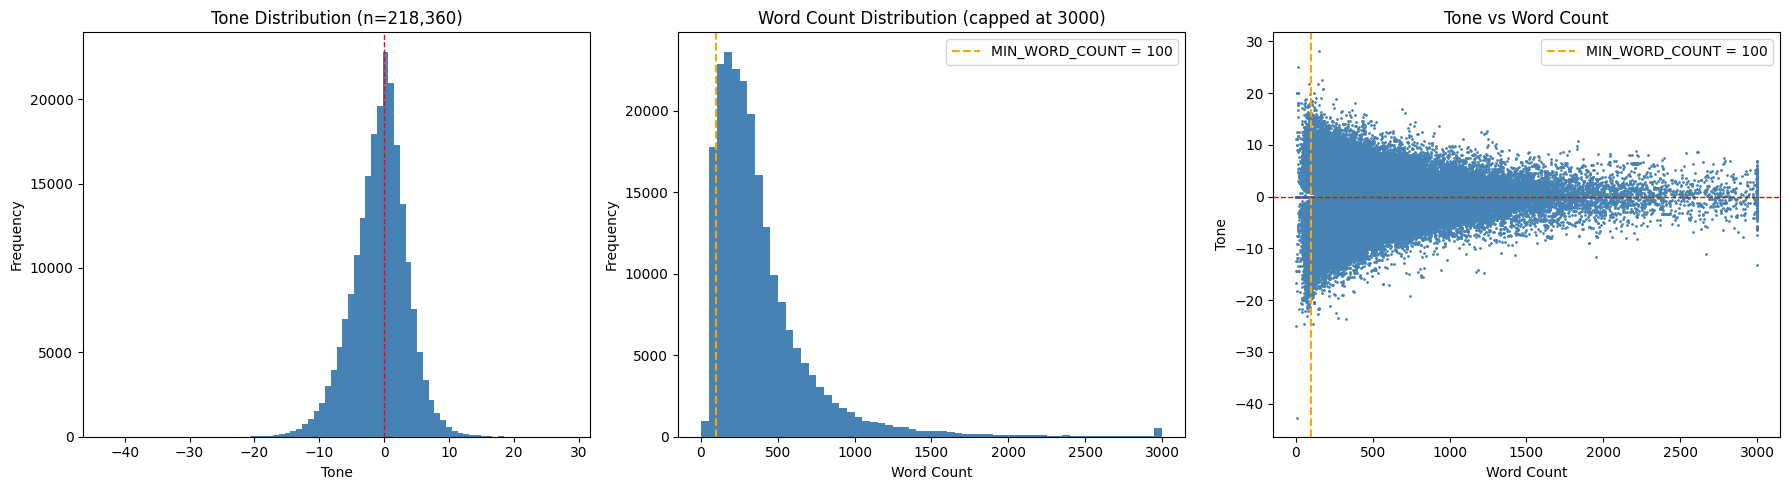

In [13]:
WORD_COUNT_DISPLAY_CAP = 3000

figure, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Left: Tone Distribution ---
tone_values = tone_dataframe["tone"].dropna()
axes[0].hist(tone_values, bins=80, color="steelblue", edgecolor="none")
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=1)
axes[0].set_title(f"Tone Distribution (n={len(tone_values):,})")
axes[0].set_xlabel("Tone")
axes[0].set_ylabel("Frequency")

# --- Middle: Word Count Distribution ---
word_count_values = tone_dataframe["word_count"].dropna()
word_count_capped = word_count_values.clip(upper=WORD_COUNT_DISPLAY_CAP)
axes[1].hist(word_count_capped, bins=60, color="steelblue", edgecolor="none")
axes[1].axvline(
    x=MIN_WORD_COUNT,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"MIN_WORD_COUNT = {MIN_WORD_COUNT}",
)
axes[1].set_title(f"Word Count Distribution (capped at {WORD_COUNT_DISPLAY_CAP})")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend()

# --- Right: Tone vs Word Count ---
valid_row_mask            = tone_dataframe["tone"].notna() & tone_dataframe["word_count"].notna()
scatter_word_count_values = tone_dataframe.loc[valid_row_mask, "word_count"].clip(upper=WORD_COUNT_DISPLAY_CAP)
scatter_tone_values       = tone_dataframe.loc[valid_row_mask, "tone"]
axes[2].scatter(scatter_word_count_values, scatter_tone_values, s=1, color="steelblue")
axes[2].axvline(
    x=MIN_WORD_COUNT,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=f"MIN_WORD_COUNT = {MIN_WORD_COUNT}",
)
axes[2].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[2].set_title("Tone vs Word Count")
axes[2].set_xlabel("Word Count")
axes[2].set_ylabel("Tone")
axes[2].legend()

plt.tight_layout()
plt.show()

**#13** - ENHANCEDTHEMES: topic coverage and most common themes

ENHANCEDTHEMES lists every detected theme in each article, along with where it is mentioned in the text.

We check what percentage of articles have at least one theme and examine which topics appear most frequently across the dataset.

We intend to use this field to classify each article into categories (e.g., Politics, Economy, Health, Crime) in the future pipeline.

In [14]:
TOP_THEMES = 40

print_section_header("ENHANCEDTHEMES")
print_null_report(raw_dataframe, "ENHANCEDTHEMES")

parsed_theme_entries      = raw_dataframe["ENHANCEDTHEMES"].apply(parse_enhanced_field)
theme_counts_per_article  = parsed_theme_entries.apply(len)
has_themes_count          = (theme_counts_per_article > 0).sum()
no_themes_count           = (theme_counts_per_article == 0).sum()

print(f"  Articles with at least one theme  : {has_themes_count:,}  ({has_themes_count / total_rows * 100:.1f}%)")
print(f"  Articles with no themes           : {no_themes_count:,}")
print(f"  Themes per article  : min={theme_counts_per_article.min()}, max={theme_counts_per_article.max()}, mean={theme_counts_per_article.mean():.2f}")

theme_counter = Counter()
for theme_entry_list in parsed_theme_entries:
    for theme_value, _ in theme_entry_list:
        theme_counter[theme_value] += 1

print(f"\n  Unique themes : {len(theme_counter):,}")
print(f"  Top {TOP_THEMES} themes:")
for theme_name, count in theme_counter.most_common(TOP_THEMES):
    print(f"    {count:>7,}  {theme_name}")


----------------------------------------------------------------------
  ENHANCEDTHEMES
----------------------------------------------------------------------
  Nulls: 18,956 / 218,394 (8.68%)
  Articles with at least one theme  : 199,438  (91.3%)
  Articles with no themes           : 18,956
  Themes per article  : min=0, max=2606, mean=38.41

  Unique themes : 7,607
  Top 40 themes:
    143,573  UNGP_FORESTS_RIVERS_OCEANS
    132,735  CRISISLEX_C07_SAFETY
    125,560  USPEC_POLITICS_GENERAL1
    125,201  EPU_ECONOMY_HISTORIC
    116,710  CRISISLEX_CRISISLEXREC
    113,371  USPEC_POLICY1
    111,298  LEADER
    106,466  WB_696_PUBLIC_SECTOR_MANAGEMENT
    105,987  GENERAL_GOVERNMENT
     99,641  GENERAL_HEALTH
     96,246  MANMADE_DISASTER_IMPLIED
     94,681  EDUCATION
     91,661  MEDICAL
     84,959  TAX_ECON_PRICE
     76,519  WB_2432_FRAGILITY_CONFLICT_AND_VIOLENCE
     75,303  WB_621_HEALTH_NUTRITION_AND_POPULATION
     73,876  TAX_FNCACT_PRESIDENT
     71,551  EPU_POLICY_GOVERN

**#14** - ENHANCEDLOCATIONS: country coverage

ENHANCEDLOCATIONS lists every location mentioned in each article.

This is the most important field for our future pipeline after TONE.

We intend to use this field to assign each article to a country by counting which country appears most often across all location mentions. Articles with no location data cannot be assigned to any country and are excluded from our sentiment scores.

In [15]:
TOP_COUNTRIES = 40

print_section_header("ENHANCEDLOCATIONS")
print_null_report(raw_dataframe, "ENHANCEDLOCATIONS")

parsed_location_lists       = raw_dataframe["ENHANCEDLOCATIONS"].apply(parse_locations)
location_counts_per_article = parsed_location_lists.apply(len)
has_locations_count         = (location_counts_per_article > 0).sum()
no_locations_count          = (location_counts_per_article == 0).sum()

print(f"  Articles with at least one location : {has_locations_count:,}  ({has_locations_count / total_rows * 100:.1f}%)")
print(f"  Articles with no locations          : {no_locations_count:,}")
print(f"  Locations per article : min={location_counts_per_article.min()}, max={location_counts_per_article.max()}, mean={location_counts_per_article.mean():.1f}")

location_type_counter = Counter()
country_code_counter  = Counter()

for location_list in parsed_location_lists:
    for location_entry in location_list:
        location_type_counter[location_entry["location_type"]] += 1
        country_code = location_entry["location_country_code"]
        if country_code:
            country_code_counter[country_code] += 1

print("\n  Location type distribution (1=Country, 2=US State, 3=US City, 4=World City, 5=World State):")
for location_type, count in sorted(location_type_counter.items()):
    print(f"    Type {location_type} : {count:,}")

print(f"\n  Unique country codes : {len(country_code_counter):,}")
print(f"  Top {TOP_COUNTRIES} country codes by mention count:")
for country_code, count in country_code_counter.most_common(TOP_COUNTRIES):
    print(f"    {country_code}  {count:>8,}")


----------------------------------------------------------------------
  ENHANCEDLOCATIONS
----------------------------------------------------------------------
  Nulls: 44,523 / 218,394 (20.39%)
  Articles with at least one location : 173,871  (79.6%)
  Articles with no locations          : 44,523
  Locations per article : min=0, max=989, mean=7.6

  Location type distribution (1=Country, 2=US State, 3=US City, 4=World City, 5=World State):
    Type 0 : 1,049
    Type 1 : 1,184,000
    Type 2 : 11,222
    Type 3 : 15,491
    Type 4 : 437,229
    Type 5 : 20,425

  Unique country codes : 231
  Top 40 country codes by mention count:
    CH   171,477
    RS   113,047
    US    77,974
    UP    74,822
    IR    73,106
    IT    61,486
    GM    57,833
    IS    57,163
    SP    49,366
    FR    48,722
    CO    46,631
    TU    43,773
    LE    43,374
    ID    41,274
    MX    39,148
    BR    37,217
    TW    32,734
    JA    32,366
    IN    28,124
    VM    24,339
    GR    24,305
 

**#15** - TRANSLATIONINFO: source language coverage

TRANSLATIONINFO records the original language of each article

We use this field to extract the original language code. This tells us how many languages are represented in the dataset.

In [16]:
TOP_LANGUAGES = 40

print_section_header("TRANSLATIONINFO - Source Language")
print_null_report(raw_dataframe, "TRANSLATIONINFO")

language_series         = raw_dataframe["TRANSLATIONINFO"].apply(parse_translationinfo)
language_present_count  = language_series.notna().sum()
language_null_count     = language_series.isna().sum()

print(f"  Source language extracted : {language_present_count:,}  ({language_present_count / total_rows * 100:.1f}%)")
print(f"  Language not found        : {language_null_count:,}")

language_counts = language_series.dropna().value_counts()
print(f"  Unique source languages   : {len(language_counts):,}")
print(f"\n  Top {TOP_LANGUAGES} source languages:")
for language_code, count in language_counts.head(TOP_LANGUAGES).items():
    bar = "#" * int(count / language_counts.max() * 50)
    print(f"    {language_code:<8} {count:>7,}  {bar}")


----------------------------------------------------------------------
  TRANSLATIONINFO - Source Language
----------------------------------------------------------------------
  Nulls: 34 / 218,394 (0.02%)
  Source language extracted : 218,360  (100.0%)
  Language not found        : 34
  Unique source languages   : 63

  Top 40 source languages:
    spa       37,253  ##################################################
    deu       19,266  #########################
    zho       18,505  ########################
    ita       15,764  #####################
    rus       15,179  ####################
    fra       10,511  ##############
    tur       10,108  #############
    por        8,924  ###########
    vie        6,919  #########
    ara        6,915  #########
    ell        6,914  #########
    ukr        4,939  ######
    ind        4,574  ######
    ron        4,000  #####
    kor        3,827  #####
    pol        3,432  ####
    srp        3,414  ####
    sqi        2,720  #

### 3.4 - Named Entities

**#16** - PERSONS and ORGANIZATIONS: who and what the articles mention

PERSONS and ORGANIZATIONS list every person name and organization name found in each article.

We do not intend to use these fields in our pipeline. We validate them here as a consistency check, recognizing names such as world leaders and major institutions helps confirm that the data comes from real news articles.

In [17]:
TOP_PERSONS       = 20
TOP_ORGANIZATIONS = 20


# --- PERSONS ---

print_section_header("PERSONS")
print_null_report(raw_dataframe, "PERSONS")

person_counter            = Counter()
person_counts_per_article = []

for raw_persons in raw_dataframe["PERSONS"].dropna():
    persons = [
        entry.strip()
        for entry in str(raw_persons).split(";")
        if entry.strip()
    ]
    person_counts_per_article.append(len(persons))
    person_counter.update(persons)

if person_counts_per_article:
    print(f"  Unique persons  : {len(person_counter):,}")
    print(f"  Persons/article : min={min(person_counts_per_article)}, max={max(person_counts_per_article)}, mean={sum(person_counts_per_article) / len(person_counts_per_article):.1f}")
    print(f"\n  Top {TOP_PERSONS} persons:")
    for person_name, count in person_counter.most_common(TOP_PERSONS):
        print(f"    {count:>7,}  {person_name}")


# --- ORGANIZATIONS ---

print_section_header("ORGANIZATIONS")
print_null_report(raw_dataframe, "ORGANIZATIONS")

organization_counter = Counter()

for raw_organizations in raw_dataframe["ORGANIZATIONS"].dropna():
    organizations = [
        entry.strip()
        for entry in str(raw_organizations).split(";")
        if entry.strip()
    ]
    organization_counter.update(organizations)

if organization_counter:
    print(f"  Unique organizations : {len(organization_counter):,}")
    print(f"\n  Top {TOP_ORGANIZATIONS} organizations:")
    for organization_name, count in organization_counter.most_common(TOP_ORGANIZATIONS):
        print(f"    {count:>7,}  {organization_name}")


----------------------------------------------------------------------
  PERSONS
----------------------------------------------------------------------
  Nulls: 142,469 / 218,394 (65.23%)
  Unique persons  : 58,348
  Persons/article : min=1, max=91, mean=1.9

  Top 20 persons:
      1,462  vladimir putin
      1,163  benjamin netanyahu
        896  pedro sanchez
        834  donald trump
        767  america latin
        554  los angeles
        544  vladimir zelenskiy
        533  jose antonio
        434  republica dominicana
        411  alvaro uribe
        342  alexis tsipra
        300  jose luis rodriguez
        255  baltic sea
        241  vladimir zelensky
        234  saint faith
        224  europe asia
        217  jose luis
        212  europe europe
        208  el pais
        202  states peter

----------------------------------------------------------------------
  ORGANIZATIONS
----------------------------------------------------------------------
  Nulls: 79,814 /

---
## Section 4 - Summary

**#17** - Pipeline Summary: how many articles survive each stage

We track how many articles pass through each stage to simulate the future pipeline, from raw download, through the word count filter, to country assignment.

Any article that fails any of these steps will not appear on the final sentiment map.

In [20]:
print(f"Data Pipeline Summary - {TARGET_DATE}")
print("=" * 80)

raw_count               = total_rows
invalid_count           = gkgrecordid_invalid_count
clean_count             = raw_count - invalid_count
passes_word_count       = above_minimum_count
country_assigned_count  = has_locations_count

print(f"  Raw articles downloaded                    : {raw_count:>8,}")
print(f"  Invalid rows (dropped)                     : {invalid_count:>8,}")
print(f"  Clean articles                             : {clean_count:>8,}")
print(f"  Pass word count filter (word_count >= {MIN_WORD_COUNT}) : {passes_word_count:>8,}  ({passes_word_count / clean_count * 100:.1f}% of clean articles) ")
print(f"  Contain location data                      : {country_assigned_count:>8,}  ({country_assigned_count / raw_count * 100:.1f}% of clean articles)")

Data Pipeline Summary - 2026-06-01 00:00:00
  Raw articles downloaded                    :  218,394
  Invalid rows (dropped)                     :       34
  Clean articles                             :  218,360
  Pass word count filter (word_count >= 100) :  200,545  (91.8% of clean articles) 
  Contain location data                      :  173,871  (79.6% of clean articles)


**#18** - Conclusion

In [21]:
print(f"Conclusion - {TARGET_DATE}")
print("=" * 80)
print()
print("  What we found:")
print(f"    - {invalid_count} invalid rows (are safe to drop).")
print(f"    - {id_collision_count:,} ID collision pairs found. Both IDs always point to different articles.")
print(f"    - {passes_word_count / clean_count * 100:.1f}% of clean articles pass the word count filter (>= {MIN_WORD_COUNT}).")
print(f"    - {country_assigned_count / clean_count * 100:.1f}% of clean articles have location data and can be assigned to a country.")
print()
print("  What the pipeline needs to handle:")
print("    1. Drop rows where GKGRECORDID does not match the expected format (invalid rows).")
print("    2. Deduplicate on DOCUMENTIDENTIFIER after all files are loaded.")
print("    3. Drop articles with word_count < MIN_WORD_COUNT before aggregation.")
print("    4. Exclude articles with no ENHANCEDLOCATIONS from country-level scoring.")

Conclusion - 2026-06-01 00:00:00

  What we found:
    - 34 invalid rows (are safe to drop).
    - 11,715 ID collision pairs found. Both IDs always point to different articles.
    - 91.8% of clean articles pass the word count filter (>= 100).
    - 79.6% of clean articles have location data and can be assigned to a country.

  What the pipeline needs to handle:
    1. Drop rows where GKGRECORDID does not match the expected format (invalid rows).
    2. Deduplicate on DOCUMENTIDENTIFIER after all files are loaded.
    3. Drop articles with word_count < MIN_WORD_COUNT before aggregation.
    4. Exclude articles with no ENHANCEDLOCATIONS from country-level scoring.
